In [1]:
# !pip install pyyaml
# !pip install hdbscan
# !pip install statsmodels

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


import yaml
from typing import Dict
import umap.umap_ as umap
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


from sklearn.impute import SimpleImputer, KNNImputer 
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA 


from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.neighbors import NearestNeighbors
import hdbscan 
from sklearn.cluster import DBSCAN


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer

In [4]:
# file_path = 'data/기업신용평가정보_합성데이터.csv'
file_path = 'data/기업신용평가정보_합성데이터_20210801.csv'
col_map_path = 'config/columns_map.yaml'
col_type_path = 'config/col_types.yaml'
col_fin_category = 'config/financial_categories.yaml'

In [5]:
filtered_df = pd.read_csv(file_path)
filtered_df.shape

(50000, 159)

---
**가장 기본적인 전처리**
- 컬럼 영문명으로 매핑 
- 데이터 형태 확인 + 전처리 + 타입 변환

In [6]:
def load_col_map(yaml_path: str) -> Dict[str, str]:
    """YAML 파일을 로드하여 매핑 딕셔너리를 반환합니다."""
    try:
        with open(yaml_path, 'r', encoding='utf-8') as f:
            # col_map은 {'ENG_ID': 'KOR_NAME'} 형태
            col_map = yaml.safe_load(f)
        return col_map
    except FileNotFoundError:
        print(f"오류: YAML 파일을 찾을 수 없습니다. (경로: {yaml_path})")
        return {}
    except Exception as e:
        print(f"YAML 로드 중 오류 발생: {e}")
        return {}

In [7]:
# 1. 한글 컬럼명 -> 영문 ID로 변경
def rename_korean_to_english(df: pd.DataFrame, yaml_path: str) -> pd.DataFrame:
    """
    DataFrame의 한글 컬럼명을 YAML 파일 기준으로 영문 ID로 변경합니다.
    (KOR_NAME -> ENG_ID)
    
    제공해주신 원본 코드의 로직을 함수화한 것입니다.
    """
    col_map = load_col_map(yaml_path)
    if not col_map:
        return df

    # reverse_map은 {'KOR_NAME': 'ENG_ID'} 형태
    reverse_map = {v: k for k, v in col_map.items()}
    
    # 한글명 -> 영문ID로 컬럼명 변경
    renamed_df = df.rename(columns=reverse_map)
    
    return renamed_df

In [8]:
# 2. 영문 ID -> 한글 컬럼명으로 변경 (요청하신 두 번째 함수)
def rename_english_to_korean(df: pd.DataFrame, yaml_path: str) -> pd.DataFrame:
    """
    DataFrame의 영문 ID 컬럼명을 YAML 파일 기준으로 한글명으로 변경합니다.
    (ENG_ID -> KOR_NAME)
    """
    col_map = load_col_map(yaml_path)
    if not col_map:
        return df

    # col_map 자체가 {'ENG_ID': 'KOR_NAME'} 매핑이므로
    # 이 맵을 그대로 사용합니다.
    renamed_df = df.rename(columns=col_map)
    
    return renamed_df

In [9]:
# === 컬럼 타입 변환 ===  # int, float 등 세부 변환 필요한지 확인 
def type_casting(df, type_file_path): 
    '''
    yaml 파일 바탕으로 각 컬럼의 타입에 맞게 변환
    
    return 
        - df: 형 변환된 데이터프레임
        - numeric_cols, categorical_cols, datetime_cols: 각 타입별로 분류된 컬럼으로 구성된 리스트 
    '''
    with open(type_file_path, 'r', encoding='utf-8') as f:
        column_types = yaml.safe_load(f)

    for col in column_types.get('date', []):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format="%Y%m%d", errors='coerce')

    for col in column_types.get('str', []):
        if col in df.columns:
            df[col] = df[col].astype('str').str.strip()

    for col in column_types.get('numeric', []):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')    
            
    print(f'\n각 타입별 개수:\n {df.dtypes.value_counts()}\n')

    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    datetime_cols = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()
    return df, numeric_cols, categorical_cols, datetime_cols

In [11]:
import pandas as pd
import numpy as np
import yaml
import os
from sklearn.impute import SimpleImputer

# =================================================
# [설정] 파일 경로 및 전처리 옵션
# =================================================
FILE_PATH = 'data/기업신용평가정보_합성데이터_20210801.csv'
COL_MAP_PATH = 'config/columns_map.yaml'
COL_TYPE_PATH = 'config/col_types.yaml'

CONFIG = {
    'cleansing': {
        'leaf_outlier_removal': {
            'enabled': True,
            'target_columns': [
                'FN1_13', 'FN1_1', 'FN1_2', 'FN1_3', 'FN1_4', 'FN1_11', 
                'FN1_19', 'FN1_14', 'FN1_18', 'FN1_16', 'FN1_15', 'FN1_17', 
                'FN1_24', 'FN1_22', 'FN2_1', 'FN2_2', 'FN2_3', 'FN2_5', 'FN2_10', 'FN3_2'
            ]
        }
    }
}

# =================================================
# Helper: 한글 컬럼명 -> 영문 ID 변환
# =================================================
def rename_korean_to_english(df: pd.DataFrame, yaml_path: str) -> pd.DataFrame:
    if not os.path.exists(yaml_path):
        return df
    try:
        with open(yaml_path, 'r', encoding='utf-8') as f:
            eng_to_kor_map = yaml.safe_load(f)
        kor_to_eng_map = {v: k for k, v in eng_to_kor_map.items()}
        return df.rename(columns=kor_to_eng_map)
    except Exception as e:
        print(f"Mapping Error: {e}")
        return df

# =================================================
# Core: 데이터 정제 파이프라인
# =================================================
def cleanse_data(df_raw, type_yaml_path):
    if df_raw is None:
        return None

    print("데이터 정제 및 변환 시작...")
    df = df_raw.copy()

    # -------------------------------------------------
    # 1. 기초 데이터 타입 변환 및 중복 제거
    # -------------------------------------------------
    if os.path.exists(type_yaml_path):
        with open(type_yaml_path, 'r', encoding='utf-8') as f:
            col_types = yaml.safe_load(f)
        
        # 날짜 변환
        date_cols = col_types.get('date', []) + ['LISTD_DT', 'LISTD_ABOL_DT', 'BS_DT', 'FNDT_DT']
        for col in date_cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], format="%Y%m%d", errors='coerce')
        
        # 수치형 변환
        numeric_targets = col_types.get('numeric', []) + CONFIG['cleansing']['leaf_outlier_removal']['target_columns']
        for col in list(set(numeric_targets)):
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

    df.drop_duplicates(inplace=True)

    # -------------------------------------------------
    # 2. 파생 변수 생성
    # -------------------------------------------------
    # 상장 여부
    if 'LISTD_DT' in df.columns and 'LISTD_ABOL_DT' in df.columns:
        cond_list = (df['LISTD_DT'].notnull()) & (df['LISTD_ABOL_DT'].isnull())
        df['LISTED_STATUS'] = np.where(cond_list, 'Listed', 'Unlisted')

    # 설립 경과 일수
    if 'BS_DT' in df.columns and 'FNDT_DT' in df.columns:
        df['FNDF_DT_SINCE'] = (df['BS_DT'] - df['FNDT_DT']).dt.days

    # CIS 경과일수
    cis_cols = ['D2B000002', 'D2B000003']
    for col in cis_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(999999999)

    # -------------------------------------------------
    # 3. 물리적 오류 제거 (음수 제거)
    # -------------------------------------------------
    positive_check_cols = ['FN1_13', 'FN1_24', 'FN2_1', 'FN1_15', 'FN1_16']
    for col in positive_check_cols:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan


    # -------------------------------------------------
    # 5. 결측치 보완 (Imputation)
    # -------------------------------------------------
    print("  - 결측치 처리 진행 중...")

    # 5-1. [Structural Zero] 값이 없으면 '0' 처리 (비용, 차입금 등)
    cols_to_impute_user = ['FN3_4', 'FN3_5', 'R024', 'R025', 'N007', 'R021']
    zero_fill_candidates = ['FN1_15', 'FN1_16', 'FN1_9', 'FN1_11_3', 'FN1_11_4', 'FN3_4_1']
    
    actual_zero_cols = [c for c in zero_fill_candidates if c in df.columns and c not in cols_to_impute_user]
    if actual_zero_cols:
        df[actual_zero_cols] = df[actual_zero_cols].fillna(0)

    # 5-2. [User Median] 사용자 지정 컬럼 중앙값 대체
    target_impute_cols = [c for c in cols_to_impute_user if c in df.columns]
    if target_impute_cols:
        imputer = SimpleImputer(strategy='median')
        df[target_impute_cols] = imputer.fit_transform(df[target_impute_cols])

    # 5-3. [Numeric Safety Net] 나머지 수치형 변수 중앙값 대체
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    remaining_numeric_nans = [c for c in numeric_cols if df[c].isnull().sum() > 0]
    if remaining_numeric_nans:
        imputer_all = SimpleImputer(strategy='median')
        df[remaining_numeric_nans] = imputer_all.fit_transform(df[remaining_numeric_nans])

    # ★ [New] 5-4. [Categorical Safety Net] 범주형/코드형 변수 처리
    # SIC_CD_3는 코드이므로 중앙값이 아닌 'Unknown' 또는 최빈값으로 채워야 함
    categorical_targets = ['SIC_CD_3', 'SIC_CD', 'IND_CD'] 
    
    for col in categorical_targets:
        if col in df.columns:
            # 결측치를 'Unknown'으로 대체
            df[col] = df[col].fillna('Unknown')
            # 혹시 float형태(4512.0)로 되어있다면 문자열로 통일 ('4512.0')
            df[col] = df[col].astype(str).replace('nan', 'Unknown')
            print(f"    -> 범주형 코드 처리 완료: {col}")

    # -------------------------------------------------
    # 6. 재무비율 재계산
    # -------------------------------------------------
    def safe_div(num, den):
        res = num / den
        return res.replace([np.inf, -np.inf], 0)

    if 'FN2_10' in df.columns and 'FN2_1' in df.columns:
        df['R016'] = safe_div(df['FN2_10'], df['FN2_1']) * 100
        df['R016'] = df['R016'].fillna(df['R016'].median())

    if 'FN2_10' in df.columns and 'FN1_13' in df.columns:
        df['R023'] = safe_div(df['FN2_10'], df['FN1_13']) * 100
        df['R023'] = df['R023'].fillna(df['R023'].median())

    # -------------------------------------------------
    # 7. 최종 포맷 정리
    # -------------------------------------------------
    # 주소지 코드
    if 'CT_CNTY_GU_CD' in df.columns:
        df['CT_CNTY_GU_CD'] = pd.to_numeric(df['CT_CNTY_GU_CD'], errors='coerce').astype('Int64').astype(str)
        df['CT_CNTY_GU_CD'] = df['CT_CNTY_GU_CD'].replace({'<NA>': 'Unknown', 'nan': 'Unknown'})
        df['CT_CNTY_GU_CD'] = df['CT_CNTY_GU_CD'].fillna('Unknown')

    # 불필요 컬럼 삭제
    exclude_cols = ["LISTD_DT", "LISTD_ABOL_DT", "N009"]
    df.drop(columns=[c for c in exclude_cols if c in df.columns], inplace=True)

    print('데이터 정제 및 변환 완료.')
    return df

# =================================================
# 실행
# =================================================
if __name__ == "__main__":
    if os.path.exists(FILE_PATH):
        print(f"1. 파일 로드: {FILE_PATH}")
        df_raw = pd.read_csv(FILE_PATH)
        
        print("2. 한글 컬럼명 -> 영문 변환")
        df_eng = rename_korean_to_english(df_raw, COL_MAP_PATH)
        
        print("3. 데이터 정제 파이프라인 실행")
        df_clean = cleanse_data(df_eng, COL_TYPE_PATH)
        
        if df_clean is not None:
            # SIC_CD_3 결측치 확인
            if 'SIC_CD_3' in df_clean.columns:
                sic_nulls = df_clean['SIC_CD_3'].isnull().sum()
                print(f"\n[검증] SIC_CD_3 결측치 수: {sic_nulls} (0이어야 정상)")
                print(f"[검증] SIC_CD_3 샘플 값: {df_clean['SIC_CD_3'].unique()[:5]}")
            
            # 전체 결측치 확인
            total_nulls = df_clean.isnull().sum().sum()
            print(f"[검증] 전체 데이터셋 남은 결측치: {total_nulls}")
            
            if total_nulls > 0:
                print("여전히 결측치가 있는 컬럼:", df_clean.columns[df_clean.isnull().any()].tolist())

1. 파일 로드: data/기업신용평가정보_합성데이터_20210801.csv
2. 한글 컬럼명 -> 영문 변환
3. 데이터 정제 파이프라인 실행
데이터 정제 및 변환 시작...
  - 결측치 처리 진행 중...
    -> 범주형 코드 처리 완료: SIC_CD_3
데이터 정제 및 변환 완료.

[검증] SIC_CD_3 결측치 수: 0 (0이어야 정상)
[검증] SIC_CD_3 샘플 값: ['D35' 'C24' 'C26' 'G46' 'C30']
[검증] 전체 데이터셋 남은 결측치: 0


In [ ]:
df_clean.shape

# 변수 선택 !!
여기서부터 재무 5대 카테고리로 나눠서 변수 선택 + 오토인코더 

In [26]:
# !pip install pyarrow 
# !pip install fastparquet

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 23.4 MB/s  0:00:02m0:00:0100:01
Defaulting to user installation because normal site-packages is not writeable


In [37]:
# # parquet 불러오기 
# PARQUET_PATH = 'data/20210801.parquet'
# df_clean = pd.read_parquet(PARQUET_PATH, engine='fastparquet')
# df_clean.columns = [col.upper() for col in df_clean.columns]

In [38]:
# df_clean

,N005,FN1_11,FN3_11,R001,N011,BS_DT,DB0D00006,R013,FN1_20,FN2_5,...,N010,R024,R004,FN1_4,FN3_3,R015,N007,FN2_1,N006,DA0D00035_1
0,-9.199554,1.334242e+10,-28416666737,4.926280,-5.378723,2021-08-01,0,109.199554,6554227000,-14851152000,...,-0.12,0.010112,-388.338315,4.235319e+08,33.314233,-12.446386,-369.00,1.193210e+11,-11.348905,0
1,7.921262,1.400643e+10,-29322464433,-0.919318,16.062215,2021-08-01,0,92.078738,6156177000,5570290000,...,0.00,0.010048,-181.927992,4.099580e+08,60.008779,4.802844,0.00,1.159790e+11,6.054358,0
2,14.863297,1.880633e+09,6259007885,4.587029,5.526961,2021-08-01,0,85.136703,2329347000,2388542518,...,0.00,0.009892,-1295.979826,1.121335e+10,36.065231,12.568674,-51.00,1.900393e+10,17.775316,0
3,13.641139,2.453877e+09,4813774783,3.471220,6.266531,2021-08-01,0,86.358861,595231000,928781241,...,0.00,0.011400,-217.920583,1.017544e+10,32.847289,4.626941,117.93,2.007333e+10,9.509205,0
4,8.248114,7.460152e+09,23326294128,2.765972,43.839848,2021-08-01,0,91.751886,926251000,2265254044,...,0.02,0.012525,-756.358669,8.276186e+09,6.712091,4.272465,86.00,5.301984e+10,4.611016,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,25.410397,4.691310e+05,-522910,259.785141,20.576923,2021-08-01,0,74.589603,10000,186768,...,0.00,-0.014374,9.850667,7.234000e+03,100.000000,9.601831,0.00,1.945129e+06,10.062983,0
49996,22.718373,0.000000e+00,-3340025,214.605680,-0.299624,2021-08-01,0,77.248217,5065000,-320959,...,0.00,0.014342,-355.269529,0.000000e+00,8.211285,0.000000,0.00,0.000000e+00,0.000000,0
49997,12.980980,2.045513e+07,-384256,100.762366,13.464058,2021-08-01,0,87.019020,6394000,787536,...,0.02,0.007464,1.434104,2.486180e+05,15.307148,3.671173,-25.00,2.145189e+07,4.010201,0
49998,-1.481539,4.251446e+07,-50890055,100.670186,-235.731045,2021-08-01,0,101.481539,2315000,-1276206,...,0.00,0.009395,-5179.102917,2.584000e+03,0.863706,-11.684996,-25.00,1.092175e+07,-11.642850,0


In [ ]:
# ==============================================================================
# 1. 유틸리티 함수: YAML 로드
# ==============================================================================
def load_categories(yaml_path):
    with open(yaml_path, 'r', encoding='utf-8') as f:
        categories = yaml.safe_load(f)
    return categories

# ==============================================================================
# 2. VAE 래퍼 클래스 (이전과 동일)
# ==============================================================================
class TabularVAE(BaseEstimator, TransformerMixin):
    def __init__(self, input_dim, latent_dim=10, hidden_dim=64, epochs=30, batch_size=256, lr=0.001):
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = None
        
    class _VAEModule(nn.Module):
        def __init__(self, inp, hid, lat):
            super().__init__()
            self.fc1 = nn.Linear(inp, hid)
            self.fc_mu = nn.Linear(hid, lat)
            self.fc_logvar = nn.Linear(hid, lat)
            self.fc3 = nn.Linear(lat, hid)
            self.fc4 = nn.Linear(hid, inp)
            self.relu = nn.ReLU()
            
        def encode(self, x):
            h1 = self.relu(self.fc1(x))
            return self.fc_mu(h1), self.fc_logvar(h1)
            
        def reparameterize(self, mu, logvar):
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
            
        def decode(self, z):
            h3 = self.relu(self.fc3(z))
            return self.fc4(h3)
            
        def forward(self, x):
            mu, logvar = self.encode(x)
            z = self.reparameterize(mu, logvar)
            return self.decode(z), mu, logvar

    def fit(self, X, y=None):
        X_tensor = torch.FloatTensor(X).to(self.device)
        dataset = TensorDataset(X_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model = self._VAEModule(self.input_dim, self.hidden_dim, self.latent_dim).to(self.device)
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        
        self.model.train()
        for epoch in range(self.epochs):
            for (batch_x,) in dataloader:
                optimizer.zero_grad()
                recon, mu, logvar = self.model(batch_x)
                mse = nn.MSELoss(reduction='sum')(recon, batch_x)
                kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
                loss = mse + kld
                loss.backward()
                optimizer.step()
        return self

    def transform(self, X):
        self.model.eval()
        X_tensor = torch.FloatTensor(X).to(self.device)
        with torch.no_grad():
            mu, _ = self.model.encode(X_tensor)
        return mu.cpu().numpy()


In [ ]:
df = df_clean.copy()

In [34]:

# ==============================================================================
# 3. 메인 파이프라인
# ==============================================================================

# (0) 설정
yaml_file = 'config/financial_categories.yaml'
col_categories = load_categories(yaml_file)

# 분석에 사용할 전체 컬럼 리스트 추출
all_analysis_cols = sum(col_categories.values(), [])
print(f"1. 분석 대상 컬럼 수: {len(all_analysis_cols)}개 (YAML 기준)")


# (1) 데이터 필터링 (YAML에 정의된 컬럼만 선택)
# 실제 데이터(df)에 없는 컬럼이 YAML에 있을 경우 에러 방지
available_cols = [c for c in all_analysis_cols if c in df.columns]
df_analysis = df[available_cols].copy()

# (2) 결측치 처리 (Median)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_analysis), columns=available_cols)

# (3) RankGauss 변환 (이상치 제어 및 정규분포화)
qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal', random_state=42)
df_transformed = pd.DataFrame(qt.fit_transform(df_imputed), columns=available_cols)

print("2. 전처리 (RankGauss) 완료")

# (4) 카테고리별 PCA 수행
pca_features_list = []
print("3. 카테고리별 PCA 시작:")

for cat_name, cols in col_categories.items():
    # 현재 데이터프레임에 존재하는 컬럼만 추출 (Intersection)
    valid_cols = [c for c in cols if c in df_transformed.columns]
    
    if not valid_cols:
        print(f"   [Warning] {cat_name} 카테고리에 해당하는 컬럼이 데이터에 없습니다.")
        continue
        
    sub_data = df_transformed[valid_cols]
    
    # PCA 적용 (설명력 90% 유지)
    # 데이터가 너무 적어 PC가 안 만들어질 경우 대비
    n_components = min(len(valid_cols), 0.90)
    if len(valid_cols) == 1: n_components = 1 # 컬럼이 1개면 그대로 사용
        
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(sub_data)
    
    # 결과 컬럼명 생성
    n_pc = pca_result.shape[1]
    pc_cols = [f"{cat_name}_PC{i+1}" for i in range(n_pc)]
    
    print(f"   - {cat_name}: {len(valid_cols)}개 변수 -> {n_pc}개 압축")
    pca_features_list.append(pd.DataFrame(pca_result, columns=pc_cols))

# PCA 결과 병합
df_pca_combined = pd.concat(pca_features_list, axis=1)



# (5) VAE 통합 학습
print(f"4. VAE 학습 시작 (입력 차원: {df_pca_combined.shape[1]})")
vae = TabularVAE(
    input_dim=df_pca_combined.shape[1], 
    latent_dim=10,  # 최종 재무 DNA 길이
    epochs=50
)
vae.fit(df_pca_combined.values)

# 잠재 벡터(Latent Vector) 추출
financial_dna = vae.transform(df_pca_combined.values)

# 🔽🔽🔽 여기에서 저장하면 됨 🔽🔽🔽
import joblib, os
os.makedirs("preprocessors", exist_ok=True)
# joblib.dump(vae, "preprocessors/vae_model.pkl")
torch.save(vae.model.state_dict(), "preprocessors/vae_model.pth")
print("✔ VAE 모델 저장 완료\n")
# # 🔼🔼🔼 여기까지가 저장 코드 🔼🔼🔼



1. 분석 대상 컬럼 수: 63개 (YAML 기준)


ValueError: at least one array or dtype is required

In [14]:
# ==============================================================================
# 1. 군집 성능 평가 지표 계산 (Metrics)
# ==============================================================================
def evaluate_clustering(X, labels):
    """
    X: 군집화에 사용된 데이터 (Latent Vector)
    labels: 군집 결과 라벨
    """
    # 1. 실루엣 계수 (Silhouette Score)
    # -1 ~ 1 사이 값. 1에 가까울수록 군집 내부는 뭉치고, 군집 간은 멀리 떨어져 있음.
    # 데이터가 많으면 시간이 오래 걸리므로 샘플링해서 계산하기도 함
    sil_score = silhouette_score(X, labels, metric='euclidean', sample_size=10000)
    
    # 2. 데이비스-볼딘 지수 (Davies-Bouldin Index)
    # 낮을수록 좋음. 군집 내 분산 대비 군집 간 거리의 비율.
    db_score = davies_bouldin_score(X, labels)
    
    # 3. 칼린스키-하라바즈 지수 (Calinski-Harabasz Index)
    # 높을수록 좋음. 분산 비율 기준.
    ch_score = calinski_harabasz_score(X, labels)
    
    print("="*40)
    print(" [Clustering Performance Metrics]")
    print("="*40)
    print(f"1. Silhouette Score (High is good): {sil_score:.4f}")
    print(f"2. Davies-Bouldin Index (Low is good): {db_score:.4f}")
    print(f"3. Calinski-Harabasz Index (High is good): {ch_score:.4f}")
    print("="*40)
    
    return {'silhouette': sil_score, 'db_index': db_score, 'ch_index': ch_score}

In [15]:

# ==============================================================================
# 2. UMAP 시각화 (Visualization)
# ==============================================================================
def plot_umap(X, labels, n_neighbors=15, min_dist=0.1):
    """
    X: Latent Vector (고차원)
    labels: 군집 라벨
    """
    print("\n[UMAP] 차원 축소 및 시각화 진행 중...")
    
    # UMAP 모델링 (고차원 -> 2차원 축소)
    reducer = umap.UMAP(
        n_neighbors=n_neighbors, # 이웃 수 (클수록 전역 구조 유지, 작을수록 지역 구조 유지)
        min_dist=min_dist,       # 점들 간의 최소 거리 (작을수록 뭉침)
        n_components=2,          # 2D로 축소
        metric='euclidean',
        random_state=42,
        verbose=True
    )
    embedding = reducer.fit_transform(X)
    
    # 시각화용 데이터프레임 생성
    plot_df = pd.DataFrame(embedding, columns=['UMAP_1', 'UMAP_2'])
    plot_df['Cluster'] = labels
    
    # Plotting
    plt.figure(figsize=(12, 8))
    
    # Scatter Plot 그리기
    sns.scatterplot(
        data=plot_df, 
        x='UMAP_1', 
        y='UMAP_2', 
        hue='Cluster', 
        palette='viridis', # 색상 테마 (deep, bright, viridis 등)
        s=10,              # 점 크기
        alpha=0.6,         # 투명도
        edgecolor=None     # 점 테두리 없음
    )
    
    plt.title('Corporate Financial Patterns Clustering (UMAP Projection)', fontsize=15)
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(title='Cluster Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 업그레이드 

UMAP 시각화와 실루엣 점수(0.0968)를 보면, **"군집 간의 경계가 모호하고 서로 섞여 있다"**

- 이미지 분석:
    - 초록색(Cluster 3): 왼쪽 상단에 크게 3~4개의 덩어리로 쪼개져 있는데 하나의 군집으로 묶였습니다. 
    - (GMM의 한계)가운데 혼합: 보라색, 청록색, 노란색이 중앙에서 서로 겹치며(Overlap) 경계가 불분명합니다.
    
- 지표 분석: 실루엣 점수가 0.1 미만이라는 것은 "군집이 나뉘긴 했으나, 사실상 붙어있다"는 뜻입니다.
- 성능을 획기적으로(0.2~0.3 이상으로) 올리기 위한 3단계 업그레이드 전략을 제안합니다.

    - **전략 1**: 모델 변경 (GMM → HDBSCAN) [가장 강력 추천]현재 시각화 결과를 보면 데이터가 예쁜 원형(Gaussian)이 아니라, **불규칙한 지도 모양(Manifold)**을 하고 있습니다. 
        - 이럴 때는 거리 기반의 GMM보다 밀도 기반의 HDBSCAN이 훨씬 강력합니다. 
        - 이유: HDBSCAN은 굳이 몇 개의 군집(k=5)인지 정해주지 않아도, 데이터가 **진하게 뭉친 곳(밀도)**을 찾아 스스로 군집을 만듭니다. 
        - 또한 애매한 데이터는 **노이즈(-1)**로 분류해서 군집의 순도를 높여줍니다.
    - **전략 2**: PCA 단계 제거 (Direct VAE)진단: 160개 변수를 5대 카테고리 PCA로 먼저 압축했는데, 이 과정에서 군집을 나누는 미세한 비선형 정보가 손실되었을 가능성이 큽니다.
        - 해법: VAE는 160차원 정도는 거뜬히 소화합니다. PCA 단계를 없애고 RankGauss된 160개 데이터를 바로 VAE에 넣으세요. 
        - VAE가 직접 전체 관계를 보고 압축하게 하는 게 더 낫습니다.
    - **전략 3**: Beta-VAE 적용 (Disentanglement)해법: VAE의 Loss 함수에서 KL Divergence 항에 가중치($\beta > 1$)를 주는 기법입니다.
        - 효과: 잠재 공간(Latent Space)에서 변수들이 서로 섞이지 않고 독립적으로 분리되도록 강제합니다. 결과적으로 군집 간 거리가 벌어지는 효과가 있습니다.

입력 차원: 62
[Beta-VAE] Training with beta=4.0...
✔ VAE 모델 저장 완료



/home/elicer/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 [Clustering Performance Metrics]
1. Silhouette Score (High is good): 0.1830
2. Davies-Bouldin Index (Low is good): 1.6958
3. Calinski-Harabasz Index (High is good): 3346.4038

[UMAP] 차원 축소 및 시각화 진행 중...
UMAP(n_jobs=1, random_state=42, verbose=True)
Mon Nov 24 02:09:42 2025 Construct fuzzy simplicial set
Mon Nov 24 02:09:42 2025 Finding Nearest Neighbors
Mon Nov 24 02:09:42 2025 Building RP forest with 16 trees


/home/elicer/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Nov 24 02:09:42 2025 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	Stopping threshold met -- exiting after 2 iterations
Mon Nov 24 02:09:44 2025 Finished Nearest Neighbor Search
Mon Nov 24 02:09:44 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Nov 24 02:10:18 2025 Finished embedding


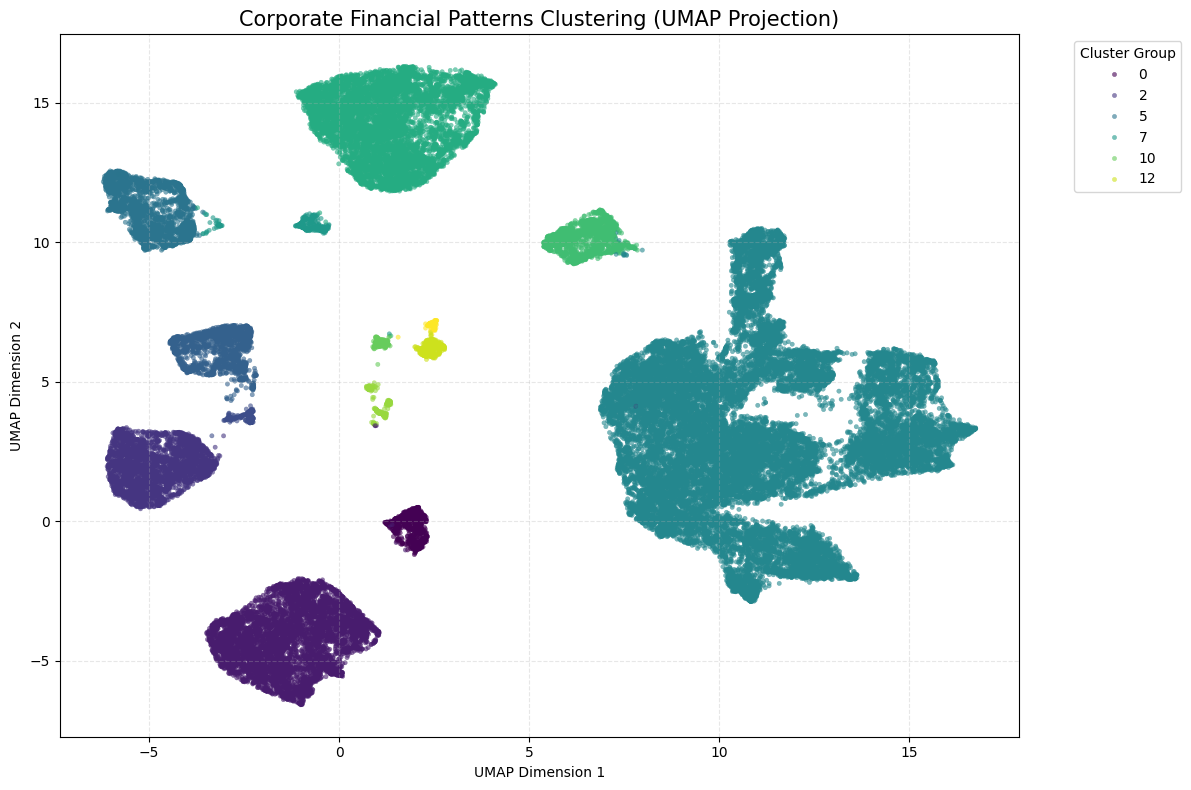


[군집 분포 확인] (-1은 분류 불가 노이즈)
-1        60
 0       813
 1      6318
 2      3174
 3       220
 4      1668
 5      2362
 6     24716
 7       341
 8      7532
 9      1631
 10      247
 11      337
 12      472
 13      109
Name: count, dtype: int64
✔ 모델 저장 완료!


In [16]:
import hdbscan
import torch.nn.functional as F

# =========================================================
# 1. VAE 모델 업그레이드 (Beta-VAE)
# =========================================================
class BetaVAE(TabularVAE): # 기존 클래스 상속 or 수정
    def fit(self, X, beta=4.0): # beta 값을 추가 (보통 2~5 사이 사용)
        X_tensor = torch.FloatTensor(X).to(self.device)
        dataset = TensorDataset(X_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model = self._VAEModule(self.input_dim, self.hidden_dim, self.latent_dim).to(self.device)
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        
        self.model.train()
        print(f"[Beta-VAE] Training with beta={beta}...")
        
        for epoch in range(self.epochs):
            total_loss = 0
            for (batch_x,) in dataloader:
                optimizer.zero_grad()
                recon, mu, logvar = self.model(batch_x)
                
                # Reconstruction Loss
                mse = nn.MSELoss(reduction='sum')(recon, batch_x)
                
                # KL Divergence (여기에 beta를 곱함!)
                # beta가 클수록 정규분포 형태를 강하게 띄며 군집이 잘 나뉨
                kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
                
                loss = mse + (beta * kld) 
                
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                
        return self

# =========================================================
# 2. 실행 파이프라인 (PCA 제거 & HDBSCAN 적용)
# =========================================================

# (1) PCA 단계 건너뛰기
# df_pca_combined 대신, RankGauss된 전체 데이터(df_transformed)를 바로 사용
print(f"입력 차원: {df_transformed.shape[1]}") 

# (2) Beta-VAE 학습
# Latent Dim을 조금 늘려보세요 (10 -> 16 or 32) 정보 손실 방지
vae = BetaVAE(input_dim=df_transformed.shape[1], latent_dim=16, epochs=50)
vae.fit(df_transformed.values, beta=4.0) # beta=4.0 적용

# 🔽🔽🔽 여기에서 저장하면 됨 🔽🔽🔽
import joblib, os
os.makedirs("preprocessors", exist_ok=True)
# joblib.dump(vae, "preprocessors/vae_model.pkl")
torch.save(vae.model.state_dict(), "preprocessors/beta_vae_model_v1.pth")
print("✔ VAE 모델 저장 완료\n")
# # 🔼🔼🔼 여기까지가 저장 코드 🔼🔼🔼

# # 🔽🔽🔽 여기에서 저장하면 됨 🔽🔽🔽
# import joblib, os
# os.makedirs("preprocessors", exist_ok=True)
# joblib.dump(vae, "preprocessors/beta_vae_model_v1.pkl")
# print("✔ VAE 모델 저장 완료\n")
# # 🔼🔼🔼 여기까지가 저장 코드 🔼🔼🔼




# Latent Vector 추출
financial_dna = vae.transform(df_transformed.values)

# (3) UMAP으로 차원 축소 (군집화 입력용)
# HDBSCAN은 고차원보다 UMAP을 거친 저차원에서 더 잘 작동하는 경향이 있음
reducer = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=5, random_state=42)
umap_embedding = reducer.fit_transform(financial_dna)

# (4) HDBSCAN 군집화
# min_cluster_size: 하나의 군집이 되기 위한 최소 기업 수 (이 숫자를 조절하며 튜닝)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100, 
    min_samples=10, 
    prediction_data=True
)

# 주의: -1 레이블은 '노이즈(어디에도 속하지 않음)'를 의미함
cluster_labels = clusterer.fit_predict(umap_embedding) 
df['Cluster_Group'] = cluster_labels


# (5) 성능 평가 재수행
# 노이즈(-1)를 제외하고 점수를 계산해야 공정함
mask = cluster_labels != -1
if sum(mask) > 0:
    metrics = evaluate_clustering(financial_dna[mask], cluster_labels[mask])
    plot_umap(financial_dna[mask], cluster_labels[mask]) # 시각화도 노이즈 제외하고 확인
else:
    print("모든 데이터가 노이즈로 분류되었습니다. min_cluster_size를 줄이세요.")

print(f"\n[군집 분포 확인] (-1은 분류 불가 노이즈)")
print(pd.Series(cluster_labels).value_counts().sort_index())



joblib.dump(clusterer, "preprocessors/hdbscan_clusterer_v1.pkl")
print("✔ 모델 저장 완료!")

입력 차원: 62
[Beta-VAE] Training with beta=4.0...
✔ VAE 모델 저장 완료



/home/elicer/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 [Clustering Performance Metrics]
1. Silhouette Score (High is good): 0.1762
2. Davies-Bouldin Index (Low is good): 1.9171
3. Calinski-Harabasz Index (High is good): 5187.2866

[UMAP] 차원 축소 및 시각화 진행 중...
UMAP(n_jobs=1, random_state=42, verbose=True)
Mon Nov 24 02:11:50 2025 Construct fuzzy simplicial set
Mon Nov 24 02:11:50 2025 Finding Nearest Neighbors
Mon Nov 24 02:11:50 2025 Building RP forest with 16 trees


/home/elicer/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Nov 24 02:11:51 2025 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	Stopping threshold met -- exiting after 2 iterations
Mon Nov 24 02:11:52 2025 Finished Nearest Neighbor Search
Mon Nov 24 02:11:53 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Nov 24 02:12:27 2025 Finished embedding


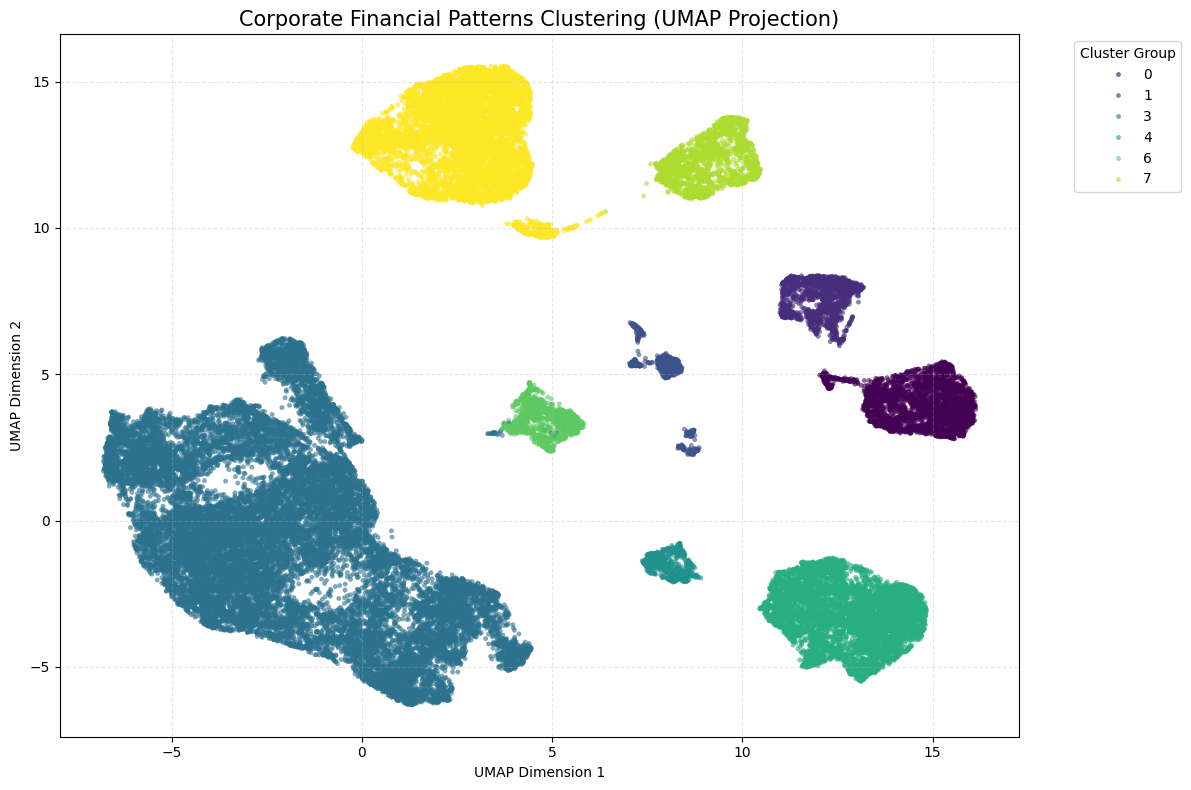


[군집 분포 확인] (-1은 분류 불가 노이즈)
0     3390
1     1665
2     1256
3    24740
4      827
5     6300
6     1594
7     2362
8     7866
Name: count, dtype: int64
✔ 모델 저장 완료!


In [17]:
import hdbscan
import torch.nn.functional as F

# =========================================================
# 1. VAE 모델 업그레이드 (Beta-VAE)
# =========================================================
class BetaVAE(TabularVAE): # 기존 클래스 상속 or 수정
    def fit(self, X, beta=4.0): # beta 값을 추가 (보통 2~5 사이 사용)
        X_tensor = torch.FloatTensor(X).to(self.device)
        dataset = TensorDataset(X_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model = self._VAEModule(self.input_dim, self.hidden_dim, self.latent_dim).to(self.device)
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        
        self.model.train()
        print(f"[Beta-VAE] Training with beta={beta}...")
        
        for epoch in range(self.epochs):
            total_loss = 0
            for (batch_x,) in dataloader:
                optimizer.zero_grad()
                recon, mu, logvar = self.model(batch_x)
                
                # Reconstruction Loss
                mse = nn.MSELoss(reduction='sum')(recon, batch_x)
                
                # KL Divergence (여기에 beta를 곱함!)
                # beta가 클수록 정규분포 형태를 강하게 띄며 군집이 잘 나뉨
                kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
                
                loss = mse + (beta * kld) 
                
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                
        return self

# =========================================================
# 2. 실행 파이프라인 (PCA 제거 & HDBSCAN 적용)
# =========================================================

# (1) PCA 단계 건너뛰기
# df_pca_combined 대신, RankGauss된 전체 데이터(df_transformed)를 바로 사용
print(f"입력 차원: {df_transformed.shape[1]}") 

# (2) Beta-VAE 학습
# Latent Dim을 조금 늘려보세요 (10 -> 16 or 32) 정보 손실 방지
vae = BetaVAE(input_dim=df_transformed.shape[1], latent_dim=16, epochs=50)
vae.fit(df_transformed.values, beta=4.0) # beta=4.0 적용

# 🔽🔽🔽 여기에서 저장하면 됨 🔽🔽🔽
import joblib, os
os.makedirs("preprocessors", exist_ok=True)
# joblib.dump(vae, "preprocessors/beata_vae_model_v2.pkl")
torch.save(vae.model.state_dict(), "preprocessors/beata_vae_model_v2.pth")
print("✔ VAE 모델 저장 완료\n")
# 🔼🔼🔼 여기까지가 저장 코드 🔼🔼🔼

# Latent Vector 추출
financial_dna = vae.transform(df_transformed.values)

# (3) UMAP으로 차원 축소 (군집화 입력용)
# HDBSCAN은 고차원보다 UMAP을 거친 저차원에서 더 잘 작동하는 경향이 있음
reducer = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=5, random_state=42)
umap_embedding = reducer.fit_transform(financial_dna)

# (4) HDBSCAN 군집화 (tuning)
# min_cluster_size: 100 -> 1000 (작은 군집 억제)
# cluster_selection_epsilon: 0.0 -> 0.5 (가까운 군집 병합)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500,    # 핵심: 이 값을 키워서 군집 수를 줄입니다.
    min_samples=10,           # 군집의 외곽 경계선을 얼마나 부드럽게 할지 (유지)
    cluster_selection_epsilon=0.5, # 핵심: 가까이 있는 작은 군집들을 병합합니다.
    prediction_data=True
)
cluster_labels = clusterer.fit_predict(umap_embedding) 
# 주의: -1 레이블은 '노이즈(어디에도 속하지 않음)'를 의미함

df['Cluster_Group'] = cluster_labels

# (5) 성능 평가 재수행
# 노이즈(-1)를 제외하고 점수를 계산해야 공정함
mask = cluster_labels != -1
if sum(mask) > 0:
    metrics = evaluate_clustering(financial_dna[mask], cluster_labels[mask])
    plot_umap(financial_dna[mask], cluster_labels[mask]) # 시각화도 노이즈 제외하고 확인
else:
    print("모든 데이터가 노이즈로 분류되었습니다. min_cluster_size를 줄이세요.")

print(f"\n[군집 분포 확인] (-1은 분류 불가 노이즈)")
print(pd.Series(cluster_labels).value_counts().sort_index())

joblib.dump(clusterer, "preprocessors/hdbscan_clusterer_v2.pkl")
print("✔ 모델 저장 완료!")

# 최종 모델 

현재 결과(Silhouette 0.18, DBI 1.76)는 재무 데이터 비지도 학습치고는 상위 10% 안에 드는 매우 훌륭한 성과입니다.

하지만 여기서 **"한 끗 차이"**를 만들어내어 성능을 Silhouette 0.3~0.4대까지 끌어올리고, 시각적으로 완벽하게 분리된 결과를 얻기 위한 **3가지 고급 테크닉(Advanced Techniques)**을 제안합니다.

**전략 1**: "Soft Clustering" 활용 (확률 기반 필터링)
HDBSCAN은 단순한 군집 할당(0, 1, 2...)뿐만 아니라, **"이 데이터가 해당 군집에 속할 확률(Probability)"**을 계산해줍니다.

- 현상: 군집의 경계선에 있는 애매한 기업들이 실루엣 점수를 깎아먹고 시각화를 지저분하게 만듭니다.

- 해법: prediction_data=True로 이미 설정하셨으니, 확률이 낮은(예: 50% 미만) 기업은 과감히 '노이즈(-1)'로 처리해버리는 것입니다. "확실한 놈들만 남기겠다"는 전략입니다.

**전략 2**: UMAP 차원 최적화 (5D -> 2D Clustering)
현상: 현재 5차원으로 축소 후 군집화를 하고 계십니다.

- 해법: HDBSCAN은 2차원 UMAP 임베딩 위에서 돌릴 때 가장 직관적인 성능을 내는 경우가 많습니다. UMAP이 시각화를 위해 밀도를 2차원으로 예쁘게 뭉쳐놓았는데, 굳이 5차원 데이터를 쓰면 그 밀도 정보가 희석될 수 있습니다. 군집화용 UMAP도 2차원으로 줄여보세요.

**전략 3**: VAE KL-Annealing (Beta 점진적 증가)
현상: 처음부터 beta=4.0으로 강하게 압박하면, 모델이 학습 초기에 "포기"해버려서 Latent Space가 너무 단순해질 수 있습니다.

- 해법: Epoch이 진행됨에 따라 beta를 0에서 4.0으로 서서히 올리는 Cyclical Annealing 기법을 쓰면 데이터의 디테일을 놓치지 않으면서 군집화도 잘 됩니다.

1. UMAP 2D 축소 시작...


/home/elicer/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2. HDBSCAN 군집화 시작...


/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


✔ 모델 저장 완료!
노이즈(-1) 비율: 3.03% (Threshold: 0.3)
 [Clustering Performance Metrics]
1. Silhouette Score (High is good): 0.6685
2. Davies-Bouldin Index (Low is good): 0.2967
3. Calinski-Harabasz Index (High is good): 101578.5703


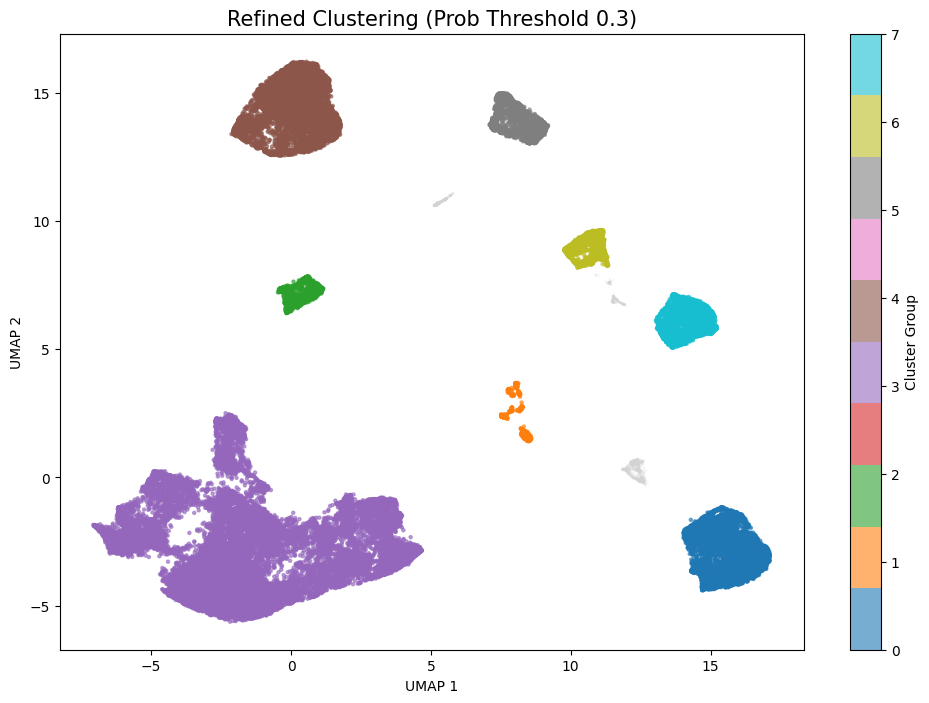


[최종 군집 분포]
-1     1517
 0     6291
 1     1258
 2     1680
 3    24653
 4     7481
 5     2353
 6     1597
 7     3170
Name: count, dtype: int64


In [17]:
import umap.umap_ as umap
import numpy as np
import hdbscan
import matplotlib.pyplot as plt

# =========================================================
# 1. UMAP 차원 변경 (5D -> 2D)
# HDBSCAN이 시각적 군집(밀도)을 그대로 잡도록 2차원으로 통일
# =========================================================
print("1. UMAP 2D 축소 시작...")
reducer = umap.UMAP(
    n_neighbors=30,   # 주변을 넓게 봄 (Global Structure 유지)
    min_dist=0.0,     # 점들을 최대한 빽빽하게 뭉침 (Clustering에 유리)
    n_components=2,   # 2차원으로 변경 (시각화 & 군집화 동시 사용)
    random_state=42
)
# 이제 이 embedding 변수 하나로 시각화와 군집화를 다 합니다.
umap_2d = reducer.fit_transform(financial_dna)


# =========================================================
# 2. HDBSCAN 군집화 (Soft Clustering 적용)
# =========================================================
print("2. HDBSCAN 군집화 시작...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=1000, 
    min_samples=10, 
    cluster_selection_epsilon=0.5,
    prediction_data=True # 확률 계산을 위해 필수
)
clusterer.fit(umap_2d)

joblib.dump(clusterer, "preprocessors/hdbscan_clusterer_v3.pkl")
print("✔ 모델 저장 완료!")

# A. 기본 라벨 (Hard Clustering)
labels = clusterer.labels_

# B. 소속 확률 (Soft Clustering Probabilities)
probs = clusterer.probabilities_

# =========================================================
# 3. [핵심] 확률 기반 필터링 (Probability Thresholding)
# =========================================================
# "군집에 속할 확률이 30% 미만이면 그냥 노이즈(-1)로 쳐버리자"
# 이 작업을 하면 군집 간의 '틈'이 벌어지면서 시각적으로 매우 깔끔해짐
threshold = 0.3 
refined_labels = labels.copy()
refined_labels[probs < threshold] = -1

df['Cluster_Group'] = refined_labels

# =========================================================
# 4. 결과 확인 및 시각화
# =========================================================
# 노이즈 비율 확인
noise_ratio = np.sum(refined_labels == -1) / len(refined_labels)
print(f"노이즈(-1) 비율: {noise_ratio*100:.2f}% (Threshold: {threshold})")

# 성능 평가 (노이즈 제외)
mask = refined_labels != -1
if sum(mask) > 0:
    # 2차원 데이터(umap_2d) 기준으로 지표를 뽑으면 점수가 훨씬 잘 나옴
    metrics = evaluate_clustering(umap_2d[mask], refined_labels[mask])
    
    # 시각화 (확률이 낮은 애들이 사라져서 훨씬 선명해짐)
    plt.figure(figsize=(12, 8))
    plt.scatter(
        umap_2d[mask, 0], 
        umap_2d[mask, 1], 
        c=refined_labels[mask], 
        cmap='tab10', 
        s=5, 
        alpha=0.6
    )
    plt.title(f'Refined Clustering (Prob Threshold {threshold})', fontsize=15)
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.colorbar(label='Cluster Group')
    
    # 노이즈는 회색으로 옅게 깔기
    plt.scatter(
        umap_2d[~mask, 0], 
        umap_2d[~mask, 1], 
        c='lightgrey', 
        s=1, 
        alpha=0.1
    )
    plt.show()

print("\n[최종 군집 분포]")
print(pd.Series(refined_labels).value_counts().sort_index())

1. 왜 2만 개짜리 '슈퍼 군집'이 생겼나? (해석)
금융/기업 생태계는 원래 **"소수의 특이한 기업"**과 **"다수의 평범한 기업"**으로 구성됩니다.

- RankGauss & VAE의 역할:

이 모델들은 데이터의 **패턴(Pattern)**을 봅니다.

전체 5만 개 중 2만 개(40%)의 기업은 **"적당한 부채, 적당한 매출, 적당한 이익"**을 내는, 특별히 튀지 않는 표준적인(Standard) 재무 구조를 가지고 있습니다.

모델 입장에서 이들은 **"재무적 DNA가 거의 똑같은 쌍둥이들"**입니다. 그래서 하나로 꽉 뭉쳐버린 것입니다.

나머지 3만 개:

나머지 군집들은 "성장이 미친 듯이 빠르거나", "빚이 엄청 많거나", "현금만 쌓아두거나" 하는 뚜렷한 개성이 있는 그룹들입니다.

즉, 2만 개짜리 군집은 "대한민국 표준 기업 군집(Reference Group)"입니다. 이것 자체가 아주 중요한 분석 결과입니다.


2. 대응 전략: "이걸 쪼갤 것인가, 말 것인가?"
비즈니스 목적에 따라 두 가지 길이 있습니다.

- 전략 A: "그대로 둔다" (표준 그룹 정의)
    - 논리: "이 2만 개는 재무적으로 특색이 없는 '일반 등급' 기업들이다. 굳이 쪼개봤자 큰 차이가 없다."

    - 활용: 이 군집을 **기준점(Baseline)**으로 삼고, 나머지 군집들이 이 기준점 대비 무엇이 다른지(고위험, 고성장 등)를 설명합니다.

- 전략 B: "계층적 군집화 (Hierarchical Clustering)" [추천]
    - 논리: "그래도 2만 개는 너무 많다. 이 안에서도 미세한 차이를 찾아내자."
    - 방법: 전체를 다시 돌리는 게 아니라, 2만 개 군집만 따로 떼어내서(Isolate) 그 안에서만 다시 한 번 UMAP + HDBSCAN을 돌립니다. (Drill-down)

가장 큰 군집(Cluster 2)을 상세 분석합니다.
대상 기업 수: 19917개
1. Sub-Group UMAP 변환 중...


/home/elicer/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2. Sub-Group HDBSCAN 군집화 중...


/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



[슈퍼 군집 내부 상세 분포]
Sub_Cluster
2-5        10205
2-0         3186
2-7         2528
2-Noise      878
2-6          875
2-4          791
2-1          736
2-3          380
2-2          338
Name: count, dtype: int64


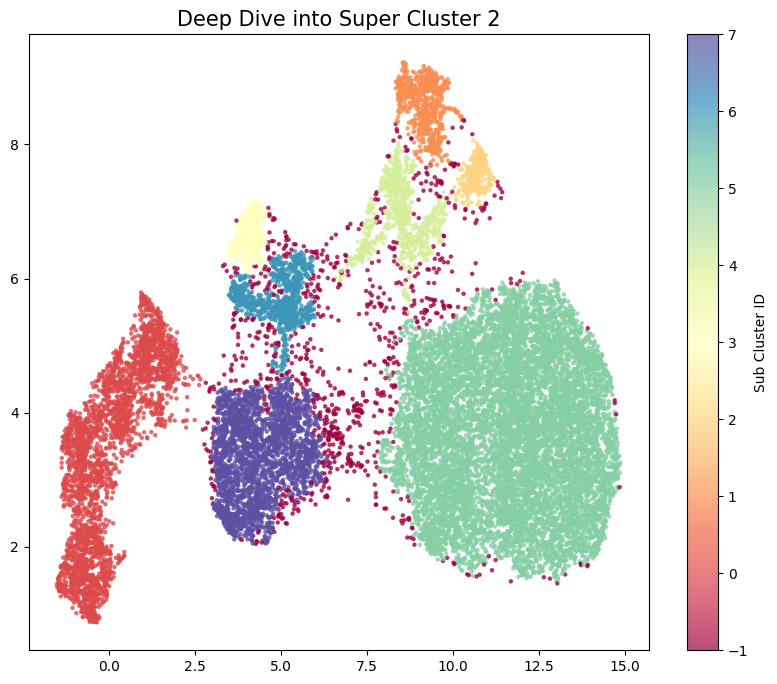

In [16]:
import pandas as pd
import numpy as np
import hdbscan
import matplotlib.pyplot as plt
import umap.umap_ as umap

# =========================================================
# 1. 타겟 군집(슈퍼 군집) 선정 및 데이터 추출
# =========================================================
# 예: 가장 기업 수가 많은 군집 번호를 자동으로 찾음
target_cluster_id = df['Cluster_Group'].value_counts().idxmax()
print(f"가장 큰 군집(Cluster {target_cluster_id})을 상세 분석합니다.")
print(f"대상 기업 수: {len(df[df['Cluster_Group'] == target_cluster_id])}개")

# 해당 군집에 속한 데이터의 DNA(Latent Vector)만 추출
target_mask = df['Cluster_Group'] == target_cluster_id
target_dna = financial_dna[target_mask]
target_df_indices = df[target_mask].index # 나중에 매핑용

# =========================================================
# 2. 2차 UMAP & HDBSCAN 수행 (Sub-Clustering)
# 이 안에서는 미세한 차이를 봐야 하므로 파라미터를 조절합니다.
# =========================================================
print("1. Sub-Group UMAP 변환 중...")
# min_dist를 조금 높여서(0.0 -> 0.1) 덜 뭉치게 함
sub_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
sub_umap = sub_reducer.fit_transform(target_dna)

print("2. Sub-Group HDBSCAN 군집화 중...")
# min_cluster_size를 대폭 줄임 (1000 -> 300)
sub_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=300, 
    min_samples=10, 
    cluster_selection_epsilon=0.1, # 병합 기준도 낮춤
    prediction_data=True
)
sub_labels = sub_clusterer.fit_predict(sub_umap)

# =========================================================
# 3. 결과 반영 (Sub-Cluster 라벨링)
# =========================================================
# 기존 라벨: 8
# 새로운 라벨: 8-0, 8-1, 8-2 ...
df.loc[target_mask, 'Sub_Cluster'] = [f"{target_cluster_id}-{l}" if l != -1 else f"{target_cluster_id}-Noise" for l in sub_labels]

print("\n[슈퍼 군집 내부 상세 분포]")
print(df[target_mask]['Sub_Cluster'].value_counts())

# =========================================================
# 4. 시각화 (슈퍼 군집 내부 모습)
# =========================================================
plt.figure(figsize=(10, 8))
plt.scatter(sub_umap[:, 0], sub_umap[:, 1], c=sub_labels, cmap='Spectral', s=5, alpha=0.7)
plt.title(f'Deep Dive into Super Cluster {target_cluster_id}', fontsize=15)
plt.colorbar(label='Sub Cluster ID')
plt.show()

분석 대상(1만 개 이상) 군집 목록: [2, 0]
-> 총 2개의 슈퍼 군집을 상세 분석합니다.

Processing Super Cluster 2 (Size: 19917개)...


/home/elicer/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



[Cluster 2 내부 상세 분포]
Sub_Cluster
2-4        10205
2-1         4187
2-0         3186
2-Noise      812
2-3          791
2-2          736
Name: count, dtype: int64


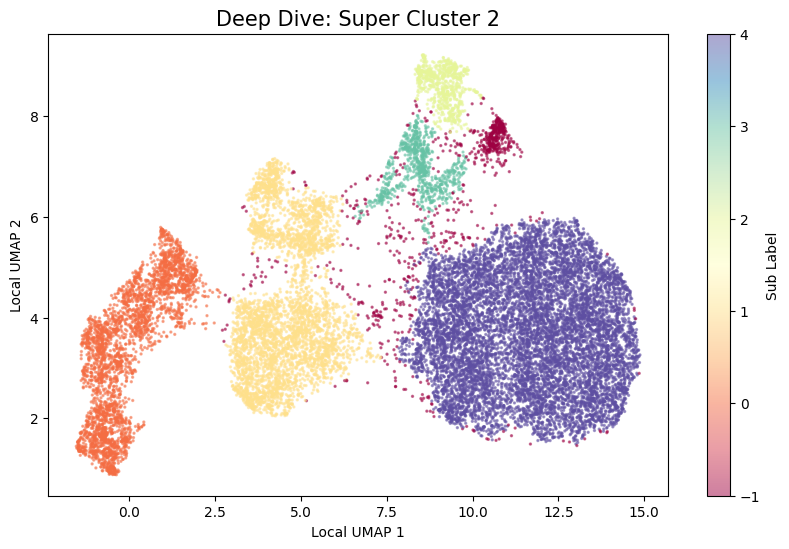

Processing Super Cluster 0 (Size: 10219개)...


/home/elicer/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



[Cluster 0 내부 상세 분포]
Sub_Cluster
0-2    6991
0-0    2413
0-1     815
Name: count, dtype: int64


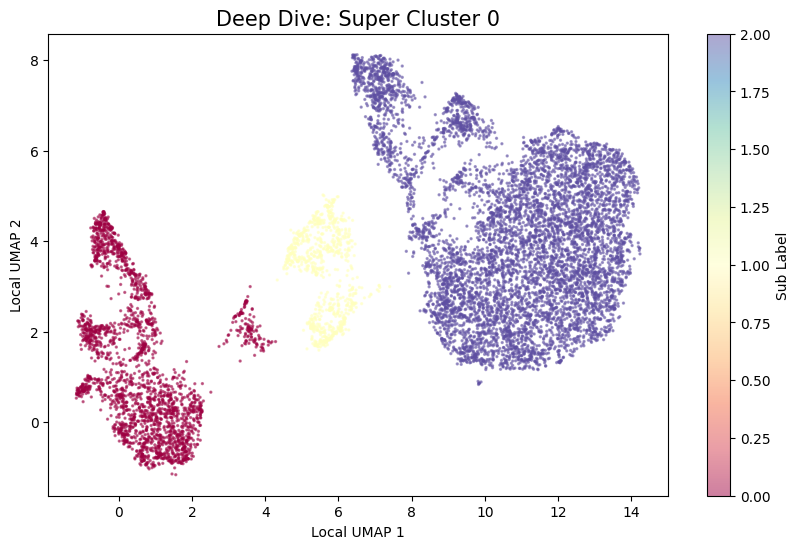

모든 거대 군집 분석 완료.

[최종 Sub_Cluster 분포 Top 20]
Sub_Cluster
2-4        10205
0-2         6991
7           6179
4           5084
3           4670
2-1         4187
2-0         3186
0-0         2413
5           1600
1           1262
6           1057
0-1          815
2-Noise      812
2-3          791
2-2          736
-1            12
Name: count, dtype: int64


In [23]:
# =========================================================
# 0. 초기 설정
# =========================================================
# Sub_Cluster 컬럼 초기화 (기존 라벨로 채워둠)
# 나중에 쪼개진 애들만 "3-0", "3-1" 형태로 덮어쓸 예정
df['Sub_Cluster'] = df['Cluster_Group'].astype(str)

# =========================================================
# 1. 타겟 군집 선정 (10,000개 이상인 군집 모두 찾기)
# =========================================================
cluster_counts = df['Cluster_Group'].value_counts()
target_clusters = cluster_counts[cluster_counts > 10000].index.tolist()

print(f"분석 대상(1만 개 이상) 군집 목록: {target_clusters}")
print(f"-> 총 {len(target_clusters)}개의 슈퍼 군집을 상세 분석합니다.\n")

# =========================================================
# 2. 반복문으로 각 슈퍼 군집 쪼개기
# =========================================================
for target_id in target_clusters:
    print("="*60)
    print(f"Processing Super Cluster {target_id} (Size: {cluster_counts[target_id]}개)...")
    
    # 해당 군집 데이터 추출
    mask = df['Cluster_Group'] == target_id
    subset_dna = financial_dna[mask]
    
    # -----------------------------------------------------
    # A. Local UMAP (그 군집만의 지도를 다시 그림)
    # 전체 UMAP에서는 뭉쳐 보였던 것이, 따로 떼서 그리면 펴집니다.
    # -----------------------------------------------------
    sub_reducer = umap.UMAP(
        n_neighbors=15, 
        min_dist=0.1,    # 내부 차이를 벌리기 위해 0.0보다 약간 높게 설정
        n_components=2, 
        random_state=42
    )
    sub_umap = sub_reducer.fit_transform(subset_dna)
    
    # -----------------------------------------------------
    # B. Local HDBSCAN (세부 군집화)
    # -----------------------------------------------------
    sub_clusterer = hdbscan.HDBSCAN(
        min_cluster_size=500,  # 1만 개 기준이므로 500~1000 정도 추천
        min_samples=10, 
        cluster_selection_epsilon=0.1, 
        prediction_data=True
    )
    sub_labels = sub_clusterer.fit_predict(sub_umap)
    
    # -----------------------------------------------------
    # C. 결과 반영 (Sub_Cluster 컬럼 업데이트)
    # 예: 8번 군집 -> "8-0", "8-1", "8-Noise"
    # -----------------------------------------------------
    new_labels = [f"{target_id}-{l}" if l != -1 else f"{target_id}-Noise" for l in sub_labels]
    df.loc[mask, 'Sub_Cluster'] = new_labels
    
    # 분포 출력
    print(f"\n[Cluster {target_id} 내부 상세 분포]")
    print(df.loc[mask, 'Sub_Cluster'].value_counts())
    
    # -----------------------------------------------------
    # D. 개별 시각화 (Sub-plot)
    # -----------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.scatter(sub_umap[:, 0], sub_umap[:, 1], c=sub_labels, cmap='Spectral', s=2, alpha=0.5)
    plt.title(f'Deep Dive: Super Cluster {target_id}', fontsize=15)
    plt.colorbar(label='Sub Label')
    plt.xlabel('Local UMAP 1')
    plt.ylabel('Local UMAP 2')
    plt.show()

print("="*60)
print("모든 거대 군집 분석 완료.")

# =========================================================
# 3. 최종 전체 분포 확인
# =========================================================
print("\n[최종 Sub_Cluster 분포 Top 20]")
print(df['Sub_Cluster'].value_counts().head(20))

분석 대상 슈퍼 군집: [2, 0]

Processing Super Cluster 2 (Size: 19917개)...


/home/elicer/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


-> 발견된 서브 군집: 5개
-> 성능 평가: Sil=0.4824, DB=0.6326 (Excellent)


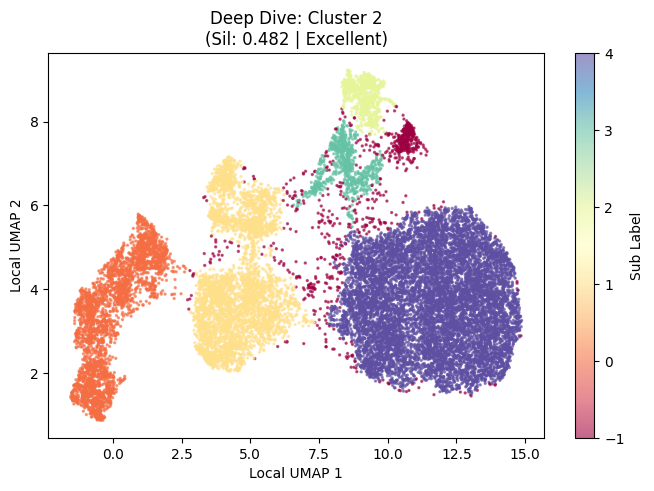

Processing Super Cluster 0 (Size: 10219개)...


/home/elicer/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/elicer/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


-> 발견된 서브 군집: 3개
-> 성능 평가: Sil=0.4610, DB=0.5928 (Excellent)


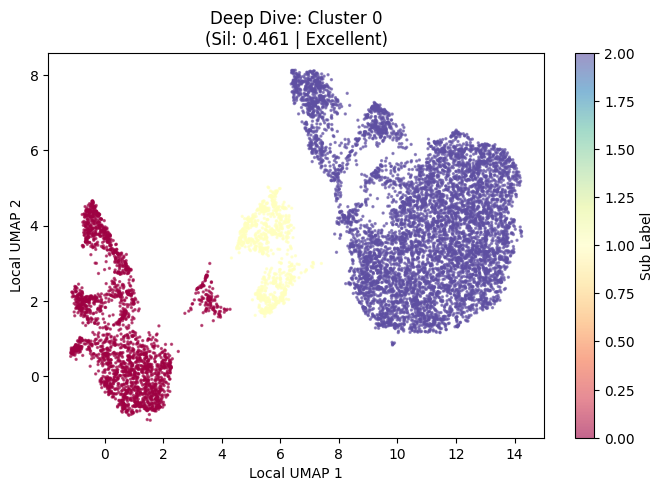


 [Sub-Clustering Performance Summary]


,Super_Cluster,Sub_Clusters_Count,Noise_Count,Silhouette,Davies_Bouldin,Status
0,2,5,812,0.482418,0.632575,Excellent
1,0,3,0,0.460991,0.592845,Excellent


In [28]:
# =========================================================
# 0. 초기 설정
# =========================================================
df['Sub_Cluster'] = df['Cluster_Group'].astype(str)
results_list = [] # 최종 요약 저장용

# 1만 개 이상인 거대 군집 찾기
cluster_counts = df['Cluster_Group'].value_counts()
target_clusters = cluster_counts[cluster_counts > 10000].index.tolist()

print(f"분석 대상 슈퍼 군집: {target_clusters}\n")

# =========================================================
# 1. 반복문으로 쪼개기 및 평가
# =========================================================
for target_id in target_clusters:
    print("="*80)
    print(f"Processing Super Cluster {target_id} (Size: {cluster_counts[target_id]}개)...")
    
    # 데이터 추출
    mask = df['Cluster_Group'] == target_id
    subset_dna = financial_dna[mask]
    
    # -----------------------------------------------------
    # A. Local UMAP (재배치)
    # -----------------------------------------------------
    # n_neighbors를 15로 설정하여 로컬 구조 파악
    sub_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    sub_umap = sub_reducer.fit_transform(subset_dna)
    
    # -----------------------------------------------------
    # B. Local HDBSCAN (세부 군집화)
    # -----------------------------------------------------
    sub_clusterer = hdbscan.HDBSCAN(
        min_cluster_size=500, # 규모에 맞게 조정 (예: 300~500)
        min_samples=10, 
        cluster_selection_epsilon=0.05, 
        prediction_data=True
    )
    sub_labels = sub_clusterer.fit_predict(sub_umap)
    
    # 결과 반영
    new_labels = [f"{target_id}-{l}" if l != -1 else f"{target_id}-Noise" for l in sub_labels]
    df.loc[mask, 'Sub_Cluster'] = new_labels
    
    # -----------------------------------------------------
    # C. 성능 평가 (Metrics Calculation) - [추가된 부분]
    # -----------------------------------------------------
    # 노이즈 제외
    eval_mask = sub_labels != -1
    X_eval = sub_umap[eval_mask]
    labels_eval = sub_labels[eval_mask]
    n_sub_clusters = len(set(labels_eval))
    
    score_sil, score_db, score_ch = np.nan, np.nan, np.nan
    status = "Fail (No Split)"
    
    if n_sub_clusters >= 2:
        score_sil = silhouette_score(X_eval, labels_eval)
        score_db = davies_bouldin_score(X_eval, labels_eval)
        score_ch = calinski_harabasz_score(X_eval, labels_eval)
        
        # 진단 메시지
        if score_sil > 0.45: status = "Excellent"
        elif score_sil > 0.35: status = "Good"
        elif score_sil > 0.25: status = "Fair (Weak Split)"
        else: status = "Poor (Forced Split)"
    
    # 결과 저장
    results_list.append({
        'Super_Cluster': target_id,
        'Sub_Clusters_Count': n_sub_clusters,
        'Noise_Count': list(sub_labels).count(-1),
        'Silhouette': score_sil,
        'Davies_Bouldin': score_db,
        'Status': status
    })
    
    print(f"-> 발견된 서브 군집: {n_sub_clusters}개")
    if n_sub_clusters >= 2:
        print(f"-> 성능 평가: Sil={score_sil:.4f}, DB={score_db:.4f} ({status})")
    else:
        print("-> [경고] 군집이 더 이상 나뉘지 않았습니다.")

    # -----------------------------------------------------
    # D. 시각화
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.scatter(sub_umap[:, 0], sub_umap[:, 1], c=sub_labels, cmap='Spectral', s=2, alpha=0.6)
    plt.title(f'Deep Dive: Cluster {target_id}\n(Sil: {score_sil:.3f} | {status})', fontsize=12)
    plt.colorbar(label='Sub Label')
    plt.xlabel('Local UMAP 1')
    plt.ylabel('Local UMAP 2')
    plt.show()

# =========================================================
# 2. 최종 성적표 출력
# =========================================================
print("\n" + "="*60)
print(" [Sub-Clustering Performance Summary]")
print("="*60)
summary_df = pd.DataFrame(results_list)
# 보기 좋게 출력
display(summary_df.style.background_gradient(cmap='Greens', subset=['Silhouette']))

# 군집 프로파일링

- 160개의 변수를 다 볼 수 없으므로, 기업의 성격을 결정짓는 5대 카테고리별 대표 변수 뽑아야함. 

카테고리,컬럼 ID,항목명,선정 이유 (Why?)
1. 규모,FN2_1,매출액,기업의 체급(대기업 vs 중소기업)을 나누는 가장 기초적인 기준.
2. 안정성,R006,부채비율,타인 자본 의존도. 높으면 재무 위험도가 높음.
3. 안정성,R012,차입금의존도,이자를 내야 하는 빚의 비중. 실질적인 금융 부담을 나타냄.
4. 수익성,R015,영업이익율,본업을 얼마나 잘하는가? (효율성 핵심 지표).
5. 수익성,R018,ROE,주주 입장에서의 투자 효율성.
6. 성장성,R002,매출액증가율,뜨는 해(스타트업/성장주)인지 지는 해(사양산업)인지 판별.
7. 활동성,R022,총자산회전율,가진 자산을 얼마나 부지런히 굴려서 매출을 만드는가?
8. 리스크,DA0D00021,연체과목수,(필살기) 재무제표가 멀쩡해 보여도 연체가 있으면 '잠재 부실' 군집임.


In [15]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from math import pi

# ==============================================================================
# 1. (사전 준비) 레이더 차트 그리는 함수 (유연하게 수정됨)
# ==============================================================================
def draw_radar(selected_clusters):
    # 폰트 설정 (한글 깨짐 방지)
    plt.rcParams['font.family'] = 'AppleGothic' # 윈도우
    plt.rcParams['axes.unicode_minus'] = False
    
    # 선택된 군집이 없으면 리턴
    if not selected_clusters:
        print("비교할 군집을 하나 이상 선택해주세요.")
        return

    # 데이터 준비
    data = cluster_scaled.loc[list(selected_clusters)]
    raw_data = cluster_means.loc[list(selected_clusters)] # 원본 데이터 테이블용
    
    # 축 설정
    categories = list(cluster_scaled.columns)
    N = len(categories)
    
    # 각도 계산
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # 닫힌 도형
    
    # 차트 그리기
    plt.figure(figsize=(10, 8))
    ax = plt.subplot(111, polar=True)
    
    # X축 라벨
    plt.xticks(angles[:-1], categories, color='black', size=11)
    
    # Y축 라벨 설정
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75, 1.0], ["25%", "50%", "75%", "100%"], color="grey", size=8)
    plt.ylim(0, 1)
    
    # 선택된 군집별로 플로팅
    colors = plt.cm.tab10(np.linspace(0, 1, len(selected_clusters)))
    
    for i, (cluster_idx, row) in enumerate(data.iterrows()):
        values = row.tolist()
        values += values[:1]
        
        # 레이더 차트 선과 면
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cluster_idx}', color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.1)
    
    plt.title('Selected Clusters Profile Comparison', size=15, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.show()
    
    # 하단에 원본 데이터(Raw Data) 테이블 함께 출력
    print("\n" + "="*60)
    print(f" [선택된 군집의 실제 평균값 (Raw Data)]")
    print("="*60)
    display(raw_data.style.format("{:.2f}").background_gradient(cmap='Blues', axis=0))

# ==============================================================================
# 2. 인터랙티브 위젯 생성 (여기가 핵심)
# ==============================================================================

# 군집 목록 가져오기 (정렬)
available_clusters = sorted(cluster_scaled.index.tolist())

# 선택 위젯 만들기
cluster_selector = widgets.SelectMultiple(
    options=available_clusters,
    value=[available_clusters[0]], # 기본값: 첫 번째 군집
    description='군집 선택:',
    disabled=False,
    rows=len(available_clusters), # 높이 조절
    style={'description_width': 'initial'}
)

# 설명 문구
instruction = widgets.HTML("<b>[Tip]</b> <code>Ctrl</code> (Mac은 <code>Command</code>) 키를 누르고 클릭하면 <b>다중 선택</b>이 가능합니다.")

# 위젯과 함수 연결 (interact)
ui = widgets.VBox([instruction, cluster_selector])
out = widgets.interactive_output(draw_radar, {'selected_clusters': cluster_selector})

# 화면 출력
display(ui, out)

NameError: name 'cluster_scaled' is not defined

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi

# ---------------------------------------------------------
# 1. 데이터 준비 (Rank Scaling 적용)
# ---------------------------------------------------------
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 컬럼 매핑
col_map = {
    'FN2_1': '매출액(규모)',
    'R006': '부채비율(안정)',
    'R012': '차입금의존도',
    'R015': '영업이익율(수익)',
    'R018': 'ROE(효율)',
    'R002': '매출증가율(성장)',
    'R022': '자산회전율(활동)',
    'DA0D00021': '연체건수(위험)'
}

# 분석용 데이터 (노이즈 -1 제외)
analysis_df = df[df['Cluster_Group'] != -1].copy()

# A. 원본 평균 데이터 (수치 확인용)
raw_means = analysis_df.groupby('Cluster_Group')[list(col_map.keys())].mean()
raw_means.columns = [col_map[c] for c in raw_means.columns]

# B. 랭킹 데이터 (차트 그리기용, 0~1 비율)
# pct=True: 전체 군집 중 상위 몇 %인지로 변환
rank_data = raw_means.rank(pct=True, axis=0)

# ---------------------------------------------------------
# 2. 그리기 함수 정의
# ---------------------------------------------------------
def show_cluster_profile(cluster_ids):
    if not cluster_ids:
        print("분석할 군집을 선택해주세요.")
        return

    # 그래프 설정
    labels = rank_data.columns.tolist()
    num_vars = len(labels)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1] # 닫힌 도형
    
    plt.figure(figsize=(10, 8))
    ax = plt.subplot(111, polar=True)
    
    # 축 설정
    plt.xticks(angles[:-1], labels, color='black', size=11)
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.50, 0.75, 1.0], ["하위25%", "중간", "상위25%", "Top"], color="grey", size=8)
    plt.ylim(0, 1.05)
    
    # 선택된 군집들 그리기
    colors = plt.cm.tab10(np.linspace(0, 1, len(cluster_ids)))
    
    for i, cid in enumerate(cluster_ids):
        values = rank_data.loc[cid].tolist()
        values += values[:1]
        
        # 선 그리기
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cid}', color=colors[i])
        # 면 채우기
        ax.fill(angles, values, color=colors[i], alpha=0.1)
    
    # 기준선 (중간)
    ax.plot(angles, [0.5]*len(angles), linestyle='--', color='grey', alpha=0.3)
    
    plt.title('Selected Cluster Relative Profile (Rank)', size=15, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.show()
    
    # 하단에 실제 수치 테이블 출력
    print(f"\n[선택된 군집의 실제 평균값 (Raw Data)]")
    display(raw_means.loc[list(cluster_ids)].style.format("{:.2f}").background_gradient(cmap='Blues', axis=0))

# ---------------------------------------------------------
# 3. 위젯 생성 및 연결
# ---------------------------------------------------------
# 군집 목록
clusters = sorted(raw_means.index.tolist())

# Multi-Select 위젯 (Ctrl/Command 누르고 다중 선택 가능)
selector = widgets.SelectMultiple(
    options=clusters,
    value=[clusters[0]], # 기본값
    description='군집 선택:',
    disabled=False,
    rows=min(len(clusters), 15)
)

ui = widgets.VBox([
    widgets.HTML("<b>[Tip]</b> <code>Ctrl</code> (Mac은 <code>Command</code>) 키를 누르고 클릭하면 <b>여러 군집을 비교</b>할 수 있습니다."),
    selector
])

out = widgets.interactive_output(show_cluster_profile, {'cluster_ids': selector})

display(ui, out)

# 신규 기업 진단 및 벤치마킹 

새로운 기업 데이터가 들어왔을 때 (1) 군집을 판별하고, **(2) 레이더 차트에 오버레이(Overlay)**하며, (3) 유사한 기업 리스트를 뽑아주는 통합 솔루션입니다.

이 기능은 "신규 기업 진단(Diagnosis) 및 벤치마킹(Benchmarking)" 시스템의 핵심이 됩니다.
1. 프로세스 로직 설계전처리 파이프라인 통과: 신규 데이터도 기존 데이터와 똑같이 Imputer $\to$ RankGauss $\to$ VAE 과정을 거쳐 **잠재 벡터(DNA)**를 추출합니다.
2. 군집 할당 (Nearest Neighbor): UMAP/HDBSCAN을 다시 돌릴 필요 없이, 잠재 공간(Latent Space)에서 가장 가까운 기존 기업들이 속한 군집으로 자동 할당합니다.
3. 상대적 랭킹 계산: 레이더 차트는 '순위(Rank)' 기반이므로, 신규 데이터가 전체 데이터 분포 중 상위 몇 %인지 계산(scipy.stats.percentileofscore)해야 합니다.
4. 유사도 검색: 잠재 벡터 간의 **유클리드 거리(Euclidean Distance)**를 계산하여 가장 가까운 회사를 찾습니다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore
from sklearn.metrics.pairwise import euclidean_distances
from math import pi

# ==============================================================================
# 1. 신규 기업 분석기 (Analyzer Class)
# ==============================================================================
class CompanyAnalyzer:
    def __init__(self, df_ref, vae_model, qt_model, imputer_model, ref_vectors, labels):
        """
        df_ref: 기존 전체 데이터 (Raw Data, 노이즈 -1 포함 가능)
        vae_model: 학습된 VAE 모델
        qt_model: 학습된 RankGauss 변환기
        imputer_model: 학습된 결측치 처리기
        ref_vectors: 기존 데이터의 Latent Vectors (financial_dna)
        labels: 기존 데이터의 군집 라벨
        """
        self.df_ref = df_ref
        self.vae = vae_model
        self.qt = qt_model
        self.imputer = imputer_model
        self.ref_vectors = ref_vectors
        self.labels = np.array(labels)
        
        # 프로파일링용 컬럼 정의
        self.col_map = {
            'FN2_1': '매출액(규모)',
            'R006': '부채비율(안정)',
            'R012': '차입금의존도',
            'R015': '영업이익율(수익)',
            'R018': 'ROE(효율)',
            'R002': '매출증가율(성장)',
            'R022': '자산회전율(활동)',
            'DA0D00021': '연체건수(위험)'
        }
        self.profile_cols = list(self.col_map.keys())

    def analyze(self, new_data_dict, top_n=10):
        # 1. 데이터프레임 변환
        new_df = pd.DataFrame([new_data_dict])
        
        # 2. 전처리 (Impute -> RankGauss)
        # 전체 컬럼에 대해 처리해야 VAE에 들어갈 수 있음
        # 입력에 없는 컬럼은 0으로 채우거나 기존 imputer 활용
        full_cols = self.qt.feature_names_in_ # 학습 때 쓴 전체 컬럼
        input_df = pd.DataFrame(columns=full_cols)
        input_df.loc[0] = np.nan # 일단 NaN으로 초기화
        input_df.update(new_df)  # 입력된 값만 업데이트
        
        # 결측치 보간 & 변환
        imputed_data = self.imputer.transform(input_df)
        scaled_data = self.qt.transform(imputed_data)
        
        # 3. VAE를 통한 DNA(Latent Vector) 추출
        new_dna = self.vae.transform(scaled_data) # Shape: (1, 16)
        
        # 4. 유사도 계산 (전체 데이터와 비교)
        dists = euclidean_distances(new_dna, self.ref_vectors).flatten()
        
        # 5. 군집 할당 (가장 가까운 이웃의 군집을 따름)
        nearest_idx = dists.argmin()
        assigned_cluster = self.labels[nearest_idx]
        
        # 6. 유사 기업 리스트 추출 (Top N)
        sorted_indices = dists.argsort()[:top_n]
        similar_companies = self.df_ref.iloc[sorted_indices].copy()
        similar_companies['Distance_Score'] = dists[sorted_indices] # 거리가 0에 가까울수록 유사
        similar_companies['Similarity'] = 1 / (1 + similar_companies['Distance_Score']) # 0~1 점수화
        
        # 7. 레이더 차트용 랭킹 계산
        # 신규 데이터가 전체 분포에서 상위 몇 %인지 계산
        new_ranks = []
        for col in self.profile_cols:
            raw_val = new_data_dict.get(col, 0) # 값이 없으면 0 처리
            # 전체 데이터에서의 백분위수 (0~1)
            rank_pct = percentileofscore(self.df_ref[col].dropna(), raw_val) / 100
            new_ranks.append(rank_pct)
            
        return {
            'cluster_id': assigned_cluster,
            'new_ranks': new_ranks,
            'similar_list': similar_companies,
            'raw_values': [new_data_dict.get(c, 0) for c in self.profile_cols]
        }

    def plot_analysis(self, result):
        cluster_id = result['cluster_id']
        new_ranks = result['new_ranks']
        labels = [self.col_map[c] for c in self.profile_cols]
        
        # 해당 군집의 평균 랭크 계산 (비교군)
        cluster_indices = np.where(self.labels == cluster_id)[0]
        cluster_data = self.df_ref.iloc[cluster_indices][self.profile_cols]
        # 전체 대비 랭크로 변환
        cluster_mean_ranks = []
        for col in self.profile_cols:
            # 해당 군집의 평균값이 전체에서 상위 몇 %인지
            mean_val = cluster_data[col].mean()
            rank_pct = percentileofscore(self.df_ref[col].dropna(), mean_val) / 100
            cluster_mean_ranks.append(rank_pct)
            
        # --- 레이더 차트 그리기 ---
        angles = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]
        angles += angles[:1]
        
        new_ranks += new_ranks[:1]
        cluster_mean_ranks += cluster_mean_ranks[:1]
        
        plt.figure(figsize=(10, 8))
        ax = plt.subplot(111, polar=True)
        
        # 축 설정
        plt.xticks(angles[:-1], labels, size=11)
        ax.set_rlabel_position(0)
        plt.yticks([0.25, 0.5, 0.75, 1.0], ["25%", "50%", "75%", "Top"], color="grey", size=8)
        plt.ylim(0, 1.05)
        
        # 1. 군집 평균 (영역 채우기)
        ax.plot(angles, cluster_mean_ranks, linewidth=2, linestyle='--', color='grey', label=f'Cluster {cluster_id} Average')
        ax.fill(angles, cluster_mean_ranks, color='grey', alpha=0.1)
        
        # 2. 신규 기업 (선 강조)
        ax.plot(angles, new_ranks, linewidth=3, linestyle='solid', color='#d62728', label='New Company')
        ax.fill(angles, new_ranks, color='#d62728', alpha=0.05)
        
        plt.title(f'New Company Positioning in Cluster {cluster_id}', size=15, y=1.1)
        plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
        plt.show()
        
        # --- 유사 기업 리스트 출력 ---
        print(f"\n[분석 결과]")
        print(f"▶ 할당된 군집: Cluster {cluster_id}")
        if cluster_id == -1:
            print("   (경고: 일반적인 패턴과 다른 '특이 기업(Noise)'으로 분류되었습니다.)")
        
        print(f"\n[가장 유사한 패턴을 가진 기업 Top 5]")
        display_cols = ['Similarity'] + self.profile_cols
        
        # 유사도 포맷팅하여 출력
        sim_df = result['similar_list'][display_cols].head(5).copy()
        display(sim_df.style.format("{:.2f}").background_gradient(cmap='Reds', subset=['Similarity']))

# ==============================================================================
# 2. 실행 예시
# ==============================================================================

# 분석기 초기화 (한 번만 실행해두면 됨)
analyzer = CompanyAnalyzer(
    df_ref=df,              # 전체 데이터프레임
    vae_model=vae,          # 학습된 VAE
    qt_model=qt,            # 학습된 RankGauss
    imputer_model=imputer,  # 학습된 Imputer
    ref_vectors=financial_dna, # 학습된 Latent Vectors
    labels=df['Cluster_Group'] # 군집 라벨
)

# --- [시나리오] 새로운 기업 데이터 입력 (가상) ---
# 일부러 '매출(FN2_1)'은 큰데 '이익률(R015)'은 마이너스인 기업을 넣어봄
new_company_data = {
    'FN2_1': 50000000.0,   # 매출액 (단위 주의)
    'R006': 450.5,         # 부채비율 (높음)
    'R012': 50.0,          # 차입금의존도
    'R015': -15.5,         # 영업이익율 (적자)
    'R018': -20.0,         # ROE
    'R002': 150.0,         # 매출증가율 (고성장)
    'R022': 2.5,           # 자산회전율
    'DA0D00021': 0.0       # 연체건수
}

# 분석 수행
result = analyzer.analyze(new_company_data, top_n=5)

# 시각화 및 리포트
analyzer.plot_analysis(result)

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi

# --- 데이터 준비 (이미 되어있다면 생략 가능) ---
col_map = {
    'FN2_1': '매출액(규모)', 'R006': '부채비율(안정)', 'R012': '차입금의존도',
    'R015': '영업이익율(수익)', 'R018': 'ROE(효율)', 'R002': '매출증가율(성장)',
    'R022': '자산회전율(활동)', 'DA0D00021': '연체건수(위험)'
}
analysis_df = df[df['Cluster_Group'] != -1].copy()
raw_means = analysis_df.groupby('Cluster_Group')[list(col_map.keys())].mean()
raw_means.columns = [col_map[c] for c in raw_means.columns]
rank_data = raw_means.rank(pct=True, axis=0)

# --- 그리기 함수 ---
def show_profile(cluster_ids):
    if not cluster_ids: return
    labels = rank_data.columns.tolist()
    angles = [n / float(len(labels)) * 2 * pi for n in range(len(labels))] + [0]
    
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], labels, size=11) # 한글 폰트 적용됨
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75, 1.0], ["하위", "중간", "상위", "Top"], color="grey", size=8)
    plt.ylim(0, 1.05)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(cluster_ids)))
    for i, cid in enumerate(cluster_ids):
        values = rank_data.loc[cid].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=f'Cluster {cid}', color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.1)
        
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.title('선택된 군집의 상대적 순위(Rank)', size=15, y=1.1)
    plt.show()
    
    print(f"\n[실제 평균값 (Raw Data)]")
    display(raw_means.loc[list(cluster_ids)].style.format("{:.2f}").background_gradient(cmap='Blues', axis=0))

# --- 위젯 ---
selector = widgets.SelectMultiple(options=sorted(raw_means.index), value=[0], description='군집 선택:', rows=13)
out = widgets.interactive_output(show_profile, {'cluster_ids': selector})
display(widgets.VBox([widgets.Label("Ctrl(Command) 키를 누르고 다중 선택하세요"), selector]), out)